In [48]:
!python3 -m pip install pyDOE3
!python3 -m pip install simpy

Homework 9
==========
<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

>📌 Question 12.1 </br>
> Describe a situation or problem from your job, everyday life, current events, etc., for which a design of experiments approach would be appropriate.

</br>

<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

>📌 Question 12.2 </br>
> To determine the value of 10 different yes/no features to the market value of a house (large yard, solar roof, etc.), a real estate agent plans to survey 50 potential buyers, showing a fictitious house with different combinations of features.  To reduce the survey size, the agent wants to show just 16 fictitious houses. Use R’s FrF2 function (in the FrF2 package) to find a fractional factorial design for this experiment: what set of features should each of the 16 fictitious houses have?  Note: the output of FrF2 is “1” (include) or  “-1” (don’t include) for each feature.

</br>

In [50]:
import  pyDOE3 
import pandas as pd
import numpy as np
import simpy
import simpy
import random
import statistics as stats


In [45]:
# Create a fractional factorial design with 15 runs and 15 factors

DOE_Experiement=pyDOE3.fracfact("a b c d")
print(DOE_Experiement)
A,B,C,D = DOE_Experiement.T

E = A * B
F = A * C
G = A * D
H = B * C
I = B * D
J = C * D


column_names = [
    "LargeYard",
    "SolarRoof",
    "Pool",
    "TwoCarGarage",
    "FinishedBasement",
    "ModernKitchen",
    "Fireplace",
    "HomeOffice",
    "WalkInCloset",
    "WalkToTransit"
]


exp_design_data = np.column_stack((A, B, C, D, E, F, G, H, I, J))
exp_design_data
# Create a DataFrame to store the experimental design
df_experiment = pd.DataFrame(exp_design_data, columns=column_names)
print(df_experiment)

[[-1. -1. -1. -1.]
 [-1. -1. -1.  1.]
 [-1. -1.  1. -1.]
 [-1. -1.  1.  1.]
 [-1.  1. -1. -1.]
 [-1.  1. -1.  1.]
 [-1.  1.  1. -1.]
 [-1.  1.  1.  1.]
 [ 1. -1. -1. -1.]
 [ 1. -1. -1.  1.]
 [ 1. -1.  1. -1.]
 [ 1. -1.  1.  1.]
 [ 1.  1. -1. -1.]
 [ 1.  1. -1.  1.]
 [ 1.  1.  1. -1.]
 [ 1.  1.  1.  1.]]
    LargeYard  SolarRoof  Pool  TwoCarGarage  FinishedBasement  ModernKitchen  \
0        -1.0       -1.0  -1.0          -1.0               1.0            1.0   
1        -1.0       -1.0  -1.0           1.0               1.0            1.0   
2        -1.0       -1.0   1.0          -1.0               1.0           -1.0   
3        -1.0       -1.0   1.0           1.0               1.0           -1.0   
4        -1.0        1.0  -1.0          -1.0              -1.0            1.0   
5        -1.0        1.0  -1.0           1.0              -1.0            1.0   
6        -1.0        1.0   1.0          -1.0              -1.0           -1.0   
7        -1.0        1.0   1.0           1.0   

<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

>📌 Question 13.1 </br>
> For each of the following distributions, give an example of data that you would expect to follow this distribution (besides the examples already discussed in class).</br>
a.	Binomial   
b.	Geometric   
c.	Poisson   
d.	Exponential  
e.	Weibull


</br>

Defect / no-defect data:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
Number of defective items: 1


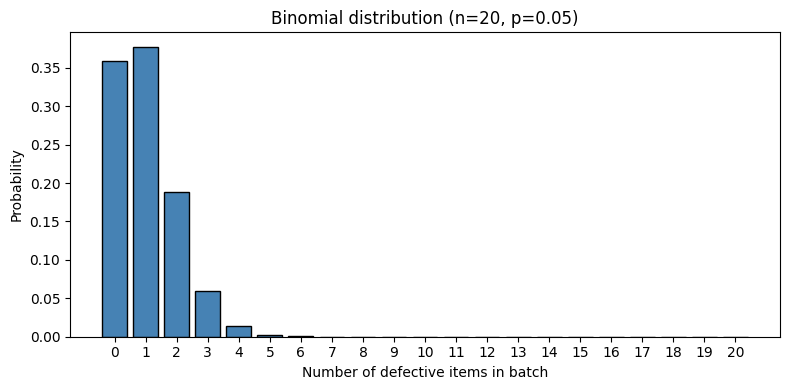

In [28]:
#Binomial Distribution Example: Simulating Defect Data in a Manufacturing Process

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters
n_items = 20          # number of items in the batch (trials)
p_defect = 0.05       # probability an item is defective (defect = 1, good = 0)

# 1) Simulate one batch of defect / no-defect data (0 = good, 1 = defect)
np.random.seed(124)
batch = np.random.binomial(n=1, p=p_defect, size=n_items)

print("Defect / no-defect data:")
print(batch)
print("Number of defective items:", batch.sum())

# 2) Binomial distribution for possible number of defects in a batch
k_values = np.arange(0, n_items + 1)               # 0,1,...,20 defects
pmf_values = binom.pmf(k_values, n_items, p_defect)

# 3) Plot binomial distribution
plt.figure(figsize=(8, 4))
plt.bar(k_values, pmf_values, color="steelblue", edgecolor="black")
plt.xlabel("Number of defective items in batch")
plt.ylabel("Probability")
plt.title(f"Binomial distribution (n={n_items}, p={p_defect:.2f})")
plt.xticks(k_values)
plt.tight_layout()
plt.show()


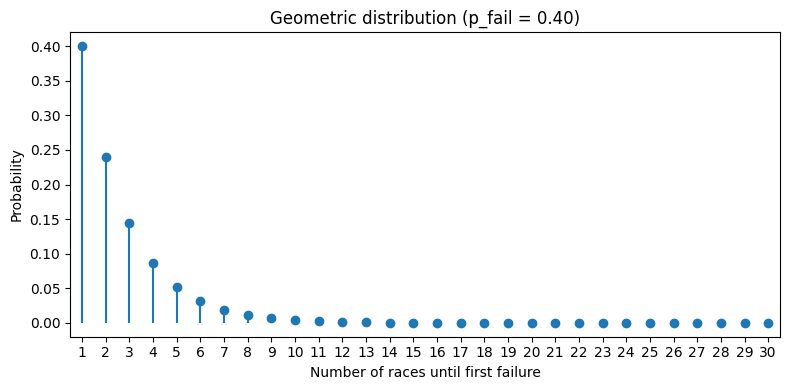

In [36]:
# geometric distribution example: Simulating the number of trials until the first success

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom

# Probability that the car fails in a given race
p_fail = 0.4   # adjust as you like (e.g., 0.05, 0.2, ...)

# Support of the geometric distribution: 1, 2, ..., max_races
max_races = 30
k = np.arange(1, max_races + 1)

# Geometric pmf: P(X = k) = (1-p)^(k-1) * p
pmf = geom.pmf(k, p_fail)

plt.figure(figsize=(8, 4))
plt.stem(k, pmf, basefmt=" ")
plt.xlabel("Number of races until first failure")
plt.ylabel("Probability")
plt.title(f"Geometric distribution (p_fail = {p_fail:.2f})")
plt.xticks(k)
plt.xlim(0.5, max_races + 0.5)
plt.tight_layout()
plt.show()


lambda = 1.50 passes/sec, T = 2.0s, mu = 3.00
P(N >= 3 passes in 2.0s) = 0.5768


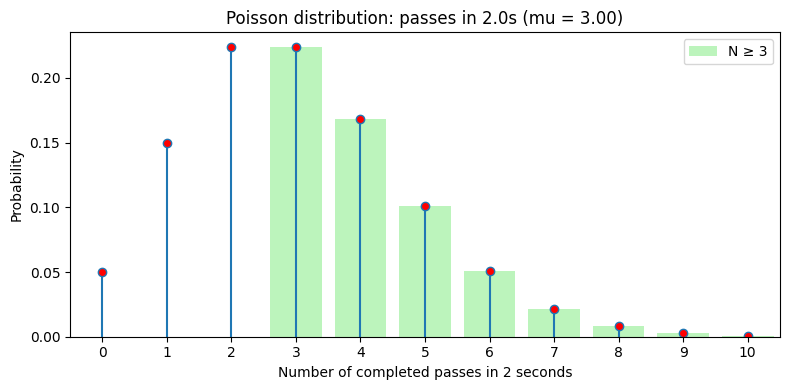

In [ ]:
# Poisson distribution example: Simulating the number of completed passes in a 2-second window
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Assume the team completes passes at an average rate lambda passes per second
lambda_rate = 1.5          # average 1.5 completed passes per second
T = 2.0                    # time window in seconds

mu = lambda_rate * T       # mean number of passes in 2 seconds

# Range of possible numbers of passes
max_k = 10
k = np.arange(0, max_k + 1)

# Poisson PMF: P(N = k)
pmf = poisson.pmf(k, mu=mu)

# Probability of at least 3 passes in 2 seconds
prob_at_least_3 = 1 - poisson.cdf(2, mu=mu)
print(f"lambda = {lambda_rate:.2f} passes/sec, T = {T:.1f}s, mu = {mu:.2f}")
print(f"P(N >= 3 passes in {T:.1f}s) = {prob_at_least_3:.4f}")

# Plot the Poisson distribution
plt.figure(figsize=(8, 4))
markerline, stemlines, baseline = plt.stem(k, pmf, basefmt=" ")
plt.setp(markerline, 'markerfacecolor', 'red')
plt.xlabel("Number of completed passes in 2 seconds")
plt.ylabel("Probability")
plt.title(f"Poisson distribution: passes in {T:.1f}s (mu = {mu:.2f})")
plt.xticks(k)
plt.xlim(-0.5, max_k + 0.5)

# Highlight k >= 3 region
k_ge3 = k[k >= 3]
pmf_ge3 = pmf[k >= 3]
plt.bar(k_ge3, pmf_ge3, color="lightgreen", alpha=0.6, label="N ≥ 3")

plt.legend()
plt.tight_layout()
plt.show()


lambda = 2.0 attacks/day
P(no attack in next 1.0 day) = 0.1353


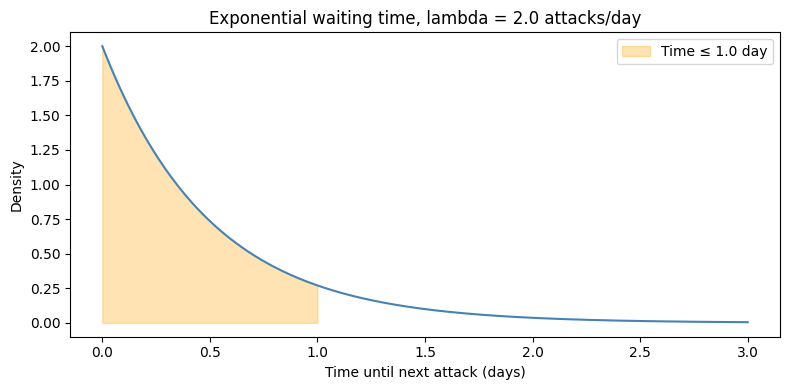

In [ ]:
# Exponential distribution example: Simulating waiting time until the next cyber attack
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Assumptions
lambda_rate = 2.0        # average 2 cyber attacks per day
# For expon in scipy, scale = 1/lambda
scale = 1 / lambda_rate  # mean waiting time between attacks

# 1) Probability of no attack in the next 24 hours
t = 1.0                   # 1 day = 24 hours
prob_no_attack = np.exp(-lambda_rate * t)
print(f"lambda = {lambda_rate:.1f} attacks/day")
print(f"P(no attack in next {t:.1f} day) = {prob_no_attack:.4f}")

# 2) Plot exponential pdf for waiting time (in days)
x = np.linspace(0, 3, 300)          # 0 to 3 days
pdf = expon.pdf(x, scale=scale)

plt.figure(figsize=(8, 4))
plt.plot(x, pdf, color="steelblue")
plt.xlabel("Time until next attack (days)")
plt.ylabel("Density")
plt.title(f"Exponential waiting time, lambda = {lambda_rate:.1f} attacks/day")

# Shade the region "no attack in next 1 day" (0 to 1)
x_shade = np.linspace(0, t, 200)
pdf_shade = expon.pdf(x_shade, scale=scale)
plt.fill_between(x_shade, pdf_shade, color="orange", alpha=0.3,
                 label=f"Time ≤ {t:.1f} day")

plt.legend()
plt.tight_layout()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:2581: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


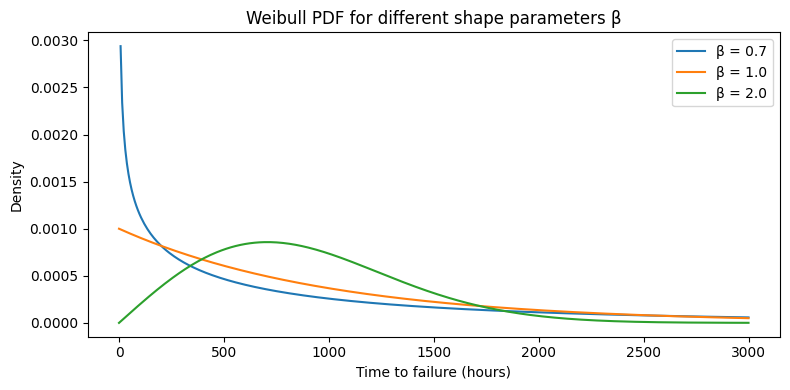

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

# Weibull parameters
eta = 1000.0  # scale parameter (characteristic life), same for all curves
betas = [0.7, 1.0, 2.0]  # shape parameters: early-fail, exponential, wear-out

x = np.linspace(0, 3000, 400)  # time, e.g. hours

plt.figure(figsize=(8, 4))

for beta in betas:
    # scipy.stats.weibull_min: c = shape, scale = eta
    pdf = weibull_min.pdf(x, c=beta, scale=eta)
    label = f"β = {beta}"
    plt.plot(x, pdf, label=label)

plt.xlabel("Time to failure (hours)")
plt.ylabel("Density")
plt.title("Weibull PDF for different shape parameters β")
plt.legend()
plt.tight_layout()
plt.show()


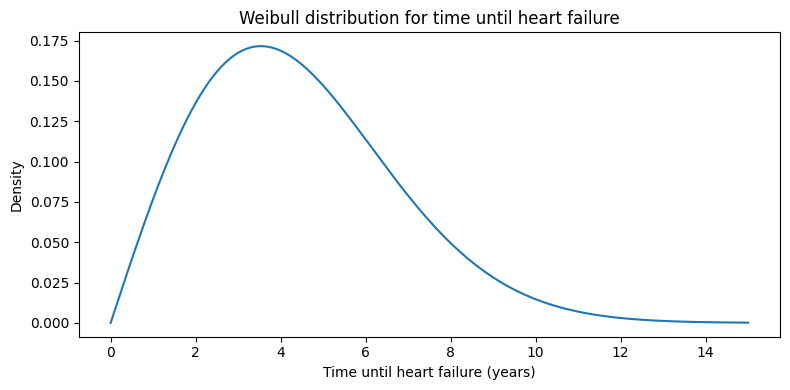

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min

# Time until heart failure (years)
beta = 2.0      # shape (>1 means risk increases with time)
eta  = 5.0      # scale (typical lifetime in years)

t = np.linspace(0, 15, 300)

# PDF = how likely different failure times are
pdf = weibull_min.pdf(t, c=beta, scale=eta)

plt.figure(figsize=(8, 4))
plt.plot(t, pdf)
plt.xlabel("Time until heart failure (years)")
plt.ylabel("Density")
plt.title("Weibull distribution for time until heart failure")
plt.tight_layout()
plt.show()


<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

>📌 Question 13.2 </br>
> In this problem you, can simulate a simplified airport security system at a busy airport. Passengers arrive according to a Poisson distribution with λ1 = 5 per minute (i.e., mean interarrival rate 1 = 0.2 minutes) to the ID/boarding-pass check queue, where there are several servers who each have exponential service time with mean rate 2 = 0.75 minutes. [Hint: model them as one block that has more than one resource.]  After that, the passengers are assigned to the shortest of the several personal-check queues, where they go through the personal scanner (time is uniformly distributed between 0.5 minutes and 1 minute). 
</br>
Use the Arena software (PC users) or Python with SimPy (PC or Mac users) to build a simulation of the system, and then vary the number of ID/boarding-pass checkers and personal-check queues to determine how many are needed to keep average wait times below 15 minutes.  [If you’re using SimPy, or if you have access to a non-student version of Arena, you can use λ1 = 50 to simulate a busier airport.]



</br>

In [ ]:
import simpy
import random
import statistics as stats

RANDOM_SEED = 123
LAMBDA_ARR = 5.0          # arrivals per minute (Poisson)
MEAN_ID_SERVICE = 0.75    # minutes, exponential
SCAN_MIN, SCAN_MAX = 0.5, 1.0  # minutes, uniform period of time spent in scanner
SIM_TIME = 8 * 60         # simulate 8 hours (minutes)

def simuation_run(num_id, num_scan,sim_time=SIM_TIME):
    random.seed(RANDOM_SEED)
    env = simpy.Environment()
    
    #Resources
    id_check = simpy.Resource(env, capacity=num_id)
    scanners = simpy.Resource(env, capacity=num_scan)
    times_in_system = []

    def passenger(env,name, id_check, scanners,times_in_system):
        arrival_time = env.now
        # ID Check
        with id_check.request() as request:
            yield request
            id_check_time = random.expovariate(1.0 / MEAN_ID_SERVICE)
            yield env.timeout(id_check_time)
        
        # Security Scan
        with scanners.request() as request:
            yield request
            scan_time = random.uniform(SCAN_MIN, SCAN_MAX)
            yield env.timeout(scan_time)
        
        total_time = env.now - arrival_time
        times_in_system.append(total_time)

    def passenger_arrivals(env, id_check, scanners,times_in_system):
        i = 0
        while True:
            inter_arrival = random.expovariate(LAMBDA_ARR)
            yield env.timeout(inter_arrival)
            i += 1
            env.process(passenger(env, f"Passenger {i}", id_check, scanners,times_in_system))

    env.process(passenger_arrivals(env, id_check, scanners,times_in_system))
    env.run(until=sim_time)
    average_time= stats.mean(times_in_system)

    return average_time, len(times_in_system)

for serversID in range(1,6):
    for scanners in range(1,6):
        avg, total_passengers = simuation_run(num_id=serversID, num_scan=scanners, sim_time=SIM_TIME)
        if avg <= 15:
            print(f"Servers= {serversID}, "+f"scanners= {scanners},"+f" Passangers:{total_passengers},"+f" Average time in system: {avg:.2f}")
        #print(f"Servers= {serversID}, "+f"scanners= {scanners},"+f" Passangers:{total_passengers},"+f" Average time in system: {avg:.2f} minutes")
    

Servers= 4, scanners= 4, Passangers:2369, Average time in system: 3.56
Servers= 4, scanners= 5, Passangers:2349, Average time in system: 3.58
Servers= 5, scanners= 4, Passangers:2392, Average time in system: 2.70
Servers= 5, scanners= 5, Passangers:2431, Average time in system: 2.00


In [76]:
import simpy
import random
import statistics as stats

RANDOM_SEED = 123
LAMBDA_ARR = 50          # arrivals per minute (Poisson)
MEAN_ID_SERVICE = 0.75    # minutes, exponential
SCAN_MIN, SCAN_MAX = 0.5, 1.0  # minutes, uniform period of time spent in scanner
SIM_TIME = 8 * 60         # simulate 8 hours (minutes)

def simuation_run(num_id, num_scan,sim_time=SIM_TIME):
    random.seed(RANDOM_SEED)
    env = simpy.Environment()
    
    #Resources
    id_check = simpy.Resource(env, capacity=num_id)
    scanners = simpy.Resource(env, capacity=num_scan)
    times_in_system = []

    def passenger(env,name, id_check, scanners,times_in_system):
        arrival_time = env.now
        # ID Check
        with id_check.request() as request:
            yield request
            id_check_time = random.expovariate(1.0 / MEAN_ID_SERVICE)
            yield env.timeout(id_check_time)
        
        # Security Scan
        with scanners.request() as request:
            yield request
            scan_time = random.uniform(SCAN_MIN, SCAN_MAX)
            yield env.timeout(scan_time)
        
        total_time = env.now - arrival_time
        times_in_system.append(total_time)

    def passenger_arrivals(env, id_check, scanners,times_in_system):
        i = 0
        while True:
            inter_arrival = random.expovariate(LAMBDA_ARR)
            yield env.timeout(inter_arrival)
            i += 1
            env.process(passenger(env, f"Passenger {i}", id_check, scanners,times_in_system))

    env.process(passenger_arrivals(env, id_check, scanners,times_in_system))
    env.run(until=sim_time)
    average_time= stats.mean(times_in_system)

    return average_time, len(times_in_system)

for serversID in range(1,50):
    for scanners in range(1,50):
        avg, total_passengers = simuation_run(num_id=serversID, num_scan=scanners, sim_time=SIM_TIME)
        if avg <= 15:
            print(f"Servers= {serversID}, "+f"scanners= {scanners},"+f" Passangers:{total_passengers},"+f" Average time in system: {avg:.2f}")
        #print(f"Servers= {serversID}, "+f"scanners= {scanners},"+f" Passangers:{total_passengers},"+f" Average time in system: {avg:.2f} minutes")
    

Servers= 35, scanners= 40, Passangers:22351, Average time in system: 11.82
Servers= 35, scanners= 49, Passangers:22381, Average time in system: 13.77
Servers= 36, scanners= 37, Passangers:23071, Average time in system: 10.17
Servers= 36, scanners= 38, Passangers:22908, Average time in system: 12.81
Servers= 36, scanners= 39, Passangers:23001, Average time in system: 9.35
Servers= 36, scanners= 40, Passangers:22702, Average time in system: 13.66
Servers= 36, scanners= 41, Passangers:22921, Average time in system: 12.23
Servers= 36, scanners= 42, Passangers:22885, Average time in system: 12.91
Servers= 36, scanners= 43, Passangers:22778, Average time in system: 11.50
Servers= 36, scanners= 44, Passangers:22881, Average time in system: 9.84
Servers= 36, scanners= 45, Passangers:22978, Average time in system: 13.60
Servers= 36, scanners= 46, Passangers:22971, Average time in system: 8.16
Servers= 36, scanners= 47, Passangers:22883, Average time in system: 10.42
Servers= 36, scanners= 48, P